# Food Price Prediction using Machine Learning

## Problem Statement
Food price fluctuations significantly impact consumers, farmers, and policymakers. 
Accurate prediction of food prices can support better economic planning and decision-making. 
This project focuses on predicting rice prices using historical data.

## Objectives
- To analyze historical food price data
- To build machine learning models for price prediction
- To compare multiple models and select the best-performing one
- To understand key factors influencing price variations

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

sns.set_style("whitegrid")
COLOR = "steelblue"

In [32]:
df = pd.read_csv("wfp_india.csv")

## Dataset Description

The dataset used in this project is sourced from the World Food Programme (WFP) India food price dataset.

### Justification for Dataset Selection:
- It is a real-world dataset with practical relevance
- Contains historical price records across different regions
- Suitable for time-based trend analysis and prediction

### Focus on Rice:
Rice is chosen as it is a staple food in India and plays a critical role in the economy, making its price prediction highly relevant.

In [33]:
print("Initial Shape:", df.shape)

Initial Shape: (68308, 18)


In [34]:
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68308 entries, 0 to 68307
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   adm0_id             68308 non-null  int64  
 1   adm0_name           68308 non-null  object 
 2   adm1_id             68308 non-null  int64  
 3   adm1_name           65864 non-null  object 
 4   mkt_id              68308 non-null  int64  
 5   mkt_name            68308 non-null  object 
 6   cm_id               68308 non-null  int64  
 7   cm_name             68308 non-null  object 
 8   cur_id              68308 non-null  int64  
 9   cur_name            68308 non-null  object 
 10  pt_id               68308 non-null  int64  
 11  pt_name             68308 non-null  object 
 12  um_id               68308 non-null  int64  
 13  um_name             68308 non-null  object 
 14  mp_month            68308 non-null  int64  
 15  mp_year             68308 non-null  int

In [35]:
print("Statistical Summary:")
print(df.describe())

Statistical Summary:
       adm0_id       adm1_id        mkt_id         cm_id   cur_id    pt_id  \
count  68308.0  68308.000000  68308.000000  68308.000000  68308.0  68308.0   
mean     115.0   7586.801121   1011.801063    167.419643     68.0     15.0   
std        0.0  18615.047396    212.112353    115.005469      0.0      0.0   
min      115.0      0.000000    921.000000     52.000000     68.0     15.0   
25%      115.0   1492.000000    933.000000     83.000000     68.0     15.0   
50%      115.0   1501.000000    947.000000    114.000000     68.0     15.0   
75%      115.0   1508.000000    962.000000    228.000000     68.0     15.0   
max      115.0  70082.000000   1887.000000    463.000000     68.0     15.0   

              um_id      mp_month       mp_year      mp_price  
count  68308.000000  68308.000000  68308.000000  68308.000000  
mean       5.476957      6.391916   2012.808968     53.909238  
std        2.131232      3.418735      4.802383     47.875561  
min        5.000000 

In [36]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
adm0_id                  0
adm0_name                0
adm1_id                  0
adm1_name             2444
mkt_id                   0
mkt_name                 0
cm_id                    0
cm_name                  0
cur_id                   0
cur_name                 0
pt_id                    0
pt_name                  0
um_id                    0
um_name                  0
mp_month                 0
mp_year                  0
mp_price                 0
mp_commoditysource       0
dtype: int64


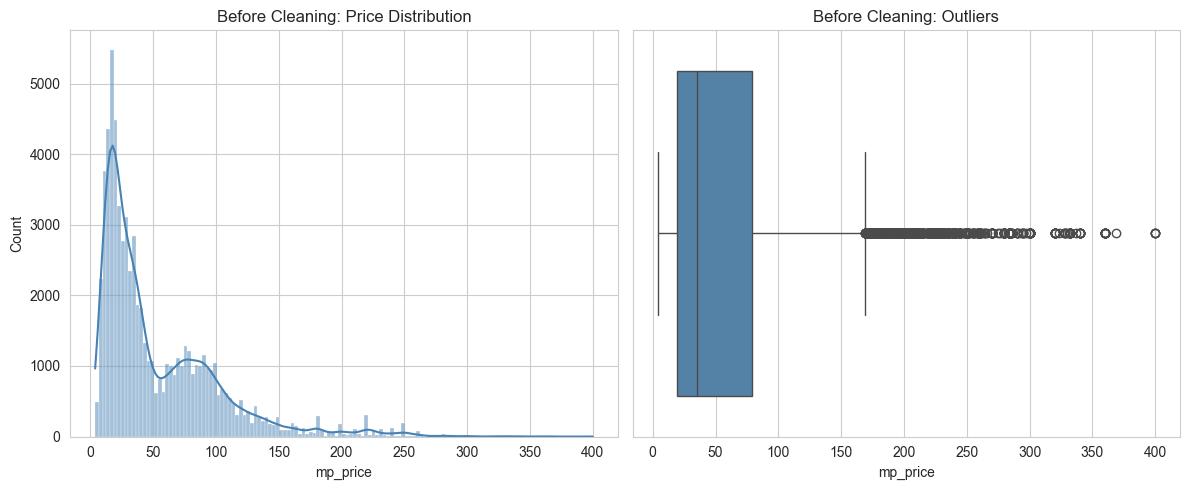

In [37]:
plt.figure(figsize=(12,5))

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(df['mp_price'], kde=True, color=COLOR)
plt.title("Before Cleaning: Price Distribution")

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=df['mp_price'], color=COLOR)
plt.title("Before Cleaning: Outliers")

plt.tight_layout()
plt.show()

In [38]:
df.drop([
    'adm0_id','adm0_name','adm1_id',
    'mkt_id','mkt_name',
    'cm_id',
    'cur_id','cur_name',
    'pt_id','pt_name',
    'um_id',
    'um_name',   
    'mp_commoditysource'
], axis=1, inplace=True)

In [39]:
print("\nColumns AFTER dropping:")
print(df.columns)

df.info()


Columns AFTER dropping:
Index(['adm1_name', 'cm_name', 'mp_month', 'mp_year', 'mp_price'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68308 entries, 0 to 68307
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   adm1_name  65864 non-null  object 
 1   cm_name    68308 non-null  object 
 2   mp_month   68308 non-null  int64  
 3   mp_year    68308 non-null  int64  
 4   mp_price   68308 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 2.6+ MB


In [40]:
df.rename(columns={
    'adm1_name': 'state',
    'cm_name': 'commodity',
    'mp_price': 'price',
    'mp_year': 'year',
    'mp_month': 'month'
}, inplace=True)

print("Columns after renaming:")
print(df.columns)

Columns after renaming:
Index(['state', 'commodity', 'month', 'year', 'price'], dtype='object')


In [41]:
df = df[df['commodity'] == 'Rice'].copy()
print("After filtering Rice:", df.shape)

After filtering Rice: (7381, 5)


In [42]:
df.drop(['commodity'],axis=1,inplace=True)

In [43]:
print("Dataset Info after filtering:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Info after filtering:
<class 'pandas.core.frame.DataFrame'>
Index: 7381 entries, 0 to 67927
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   state   7193 non-null   object 
 1   month   7381 non-null   int64  
 2   year    7381 non-null   int64  
 3   price   7381 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 288.3+ KB

Missing Values:
state    188
month      0
year       0
price      0
dtype: int64


In [44]:
df.head()

,state,month,year,price
0,Tripura,1,1996,8.00
1,Tripura,3,1996,8.50
2,Tripura,4,1996,8.75
3,Tripura,5,1996,8.75
4,Tripura,6,1996,8.50


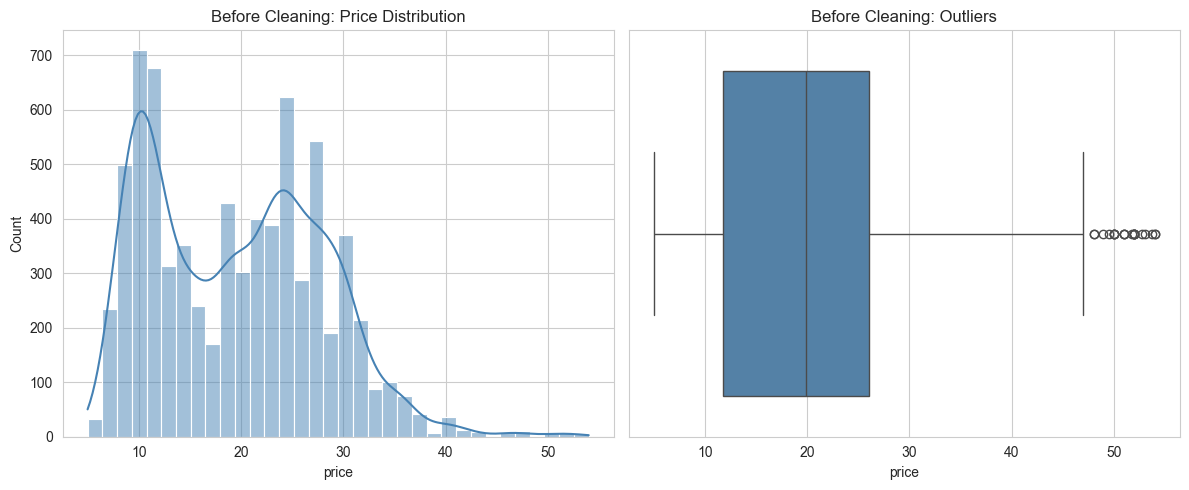

In [45]:
plt.figure(figsize=(12,5))

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(df['price'], kde=True, color=COLOR)
plt.title("Before Cleaning: Price Distribution")

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=df['price'], color=COLOR)
plt.title("Before Cleaning: Outliers")

plt.tight_layout()
plt.show()

## Data Preprocessing

The dataset undergoes several preprocessing steps to ensure quality and consistency:

- Missing values are handled using median imputation
- Outliers are removed using percentile-based filtering (1% - 99%)
- Categorical variables are encoded into numerical format

These steps improve model performance and reliability.

In [46]:
df['price'] = df.groupby('state')['price'].transform(
    lambda x: x.fillna(x.median())
)

In [47]:
q_low = df['price'].quantile(0.01)
q_high = df['price'].quantile(0.99)

df = df[(df['price'] >= q_low) & (df['price'] <= q_high)]

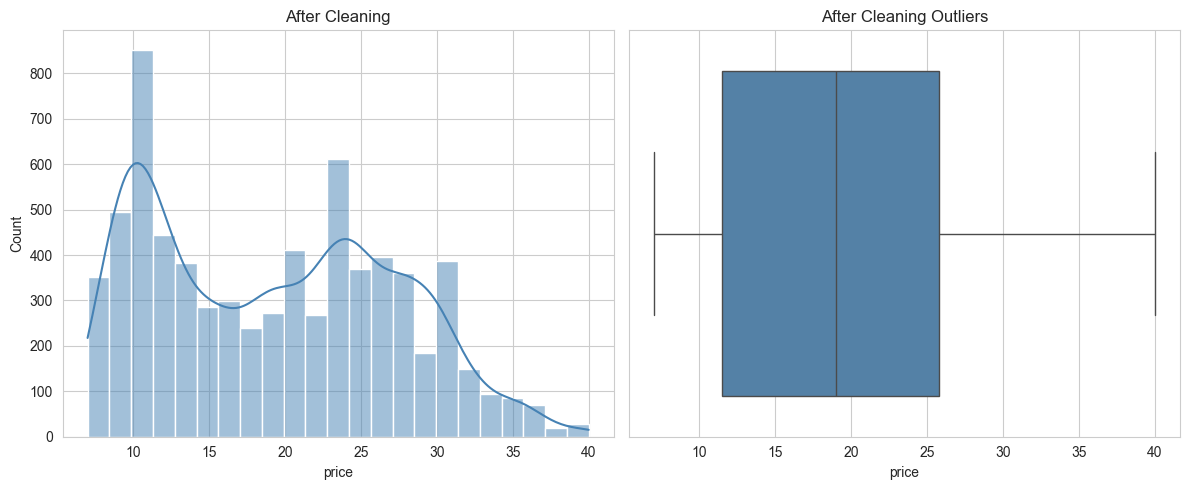

In [48]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['price'], kde=True, color=COLOR)
plt.title("After Cleaning")

plt.subplot(1,2,2)
sns.boxplot(x=df['price'], color=COLOR)
plt.title("After Cleaning Outliers")

plt.tight_layout()
plt.show()

## Feature Engineering

To enhance model performance, additional features are created:

- **time_index**: Captures the progression of time for trend analysis
- **month_sin and month_cos**: Represent cyclical patterns to capture seasonality

These features help the model better understand temporal patterns in the data.

In [49]:
df['time_index'] = df['year']*12 + df['month']

df['sin_month'] = np.sin(2*np.pi*df['month']/12)
df['cos_month'] = np.cos(2*np.pi*df['month']/12)

In [50]:
df = pd.get_dummies(df, columns=['state'], drop_first=True)

In [51]:
df.head()

,month,year,price,time_index,sin_month,cos_month,state_$Jharkhand,state_$Puducherry,state_$Uttarakhand,state_Andaman and Nicobar,...,state_Meghalaya,state_Mizoram,state_Nagaland,state_Orissa,state_Punjab,state_Rajasthan,state_Tamil Nadu,state_Tripura,state_Uttar Pradesh,state_West Bengal
0,1,1996,8.00,23953,5.000000e-01,8.660254e-01,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,3,1996,8.50,23955,1.000000e+00,6.123234e-17,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,4,1996,8.75,23956,8.660254e-01,-5.000000e-01,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,5,1996,8.75,23957,5.000000e-01,-8.660254e-01,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,6,1996,8.50,23958,1.224647e-16,-1.000000e+00,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [52]:
max_year = df['year'].max()

train = df[df['year'] < max_year]
test  = df[df['year'] == max_year]

print("Train shape:", train.shape)
print("Test shape:", test.shape)

X_train = train.drop('price', axis=1)
y_train = train['price']

X_test = test.drop('price', axis=1)
y_test = test['price']

Train shape: (6742, 33)
Test shape: (311, 33)


## Model Selection

The following machine learning models are implemented:

- **Linear Regression**: Serves as a baseline model for comparison
- **Decision Tree Regressor**: Captures non-linear relationships in data
- **Random Forest Regressor**: An ensemble model that reduces overfitting and improves prediction accuracy

Using multiple models allows for a comprehensive performance comparison.

In [53]:
lr = LinearRegression()
dt = DecisionTreeRegressor(random_state=42)
rf = RandomForestRegressor(n_estimators=100, random_state=42)

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [54]:
results = {}

for name, model in [('Linear', lr), ('DecisionTree', dt), ('RandomForest', rf)]:
    
    preds = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    results[name] = [mae, rmse, r2]

results_df = pd.DataFrame(results, index=['MAE','RMSE','R2']).T
print(results_df)

                   MAE      RMSE        R2
Linear        2.597501  3.543811  0.415877
DecisionTree  1.900857  2.647964  0.673873
RandomForest  1.991046  2.672341  0.667840


## Result Analysis

The performance of the models is evaluated using MAE, RMSE, and R² score.

- Random Forest shows the best performance due to its ability to handle complex and non-linear patterns
- Linear Regression performs comparatively weaker due to its assumption of linearity
- Decision Tree provides moderate performance but is prone to overfitting

### Bias-Variance Insight:
- Linear Regression → Linear Regression exhibits high bias and underfits the data.
- Decision Tree → Decision Tree has low bias but high variance, leading to overfitting.
- Random Forest → Random Forest reduces variance by combining multiple trees, resulting in better generalization. (Balanced (Best Model))

Conclusion:
Random Forest is the most suitable model for this task.

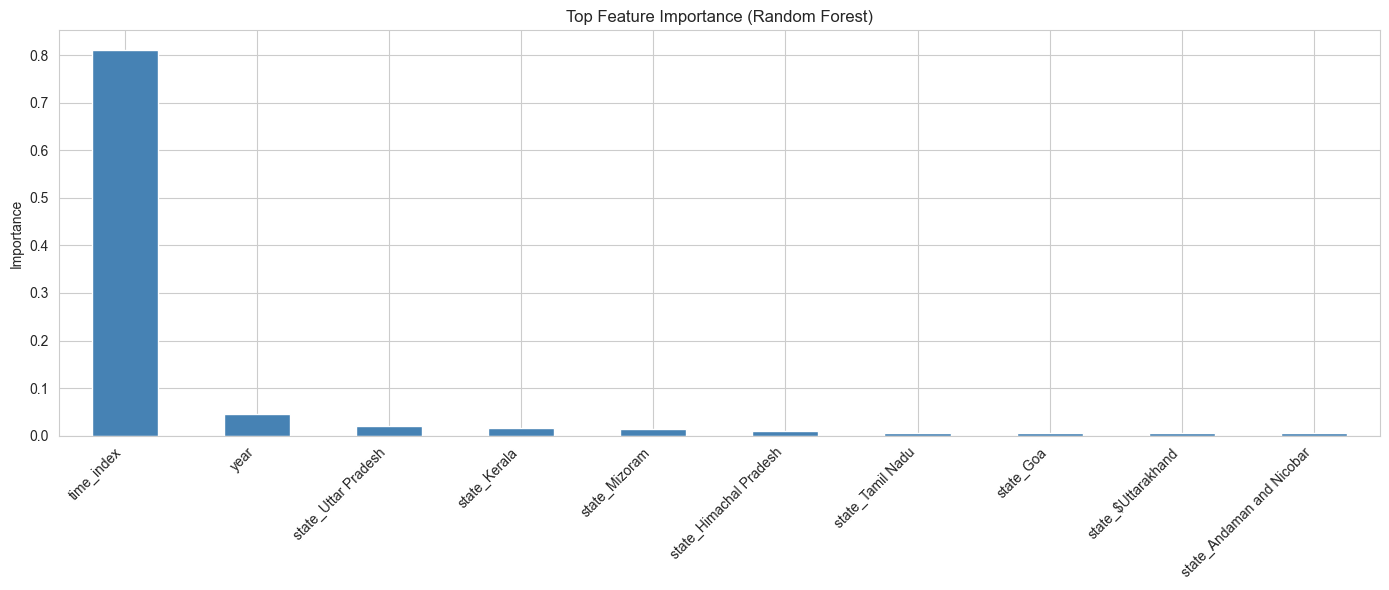

In [55]:
# 🔹 Feature Importance (Random Forest)

importances = rf.feature_importances_
features = X_train.columns

feat_df = pd.Series(importances, index=features).sort_values(ascending=False)[:10]

plt.figure(figsize=(14,6))

feat_df.plot(kind='bar', color=COLOR)

plt.title("Top Feature Importance (Random Forest)")
plt.ylabel("Importance")

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

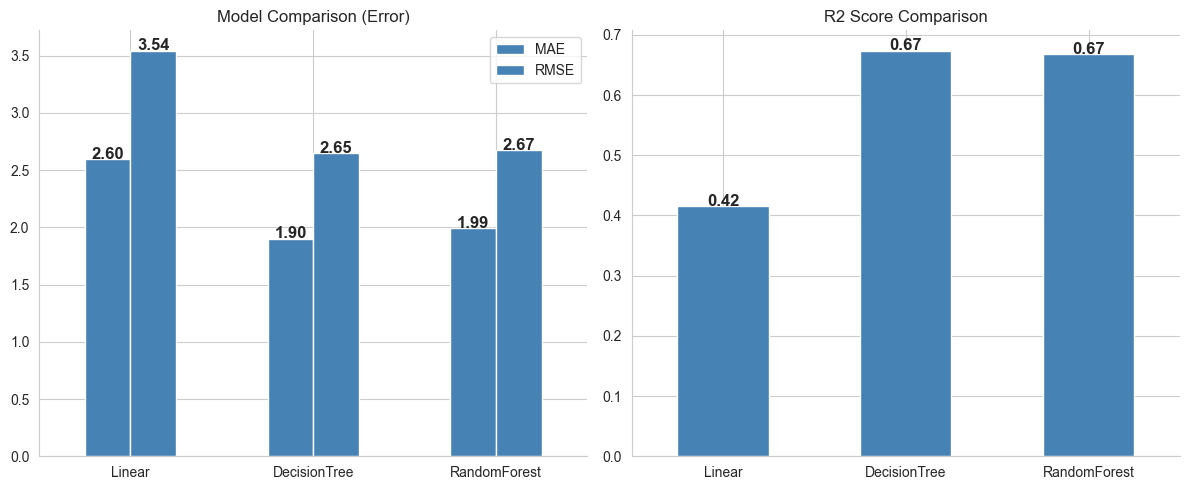

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# 🔹 Error Graph
results_df[['MAE','RMSE']].plot(kind='bar', ax=axes[0], color=COLOR)
axes[0].set_title("Model Comparison (Error)")
axes[0].set_xticklabels(results_df.index, rotation=0)

# Add values
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.2f', padding=-2, fontsize=12, fontweight='bold')


for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# 🔹 R2 Graph
results_df['R2'].plot(kind='bar', ax=axes[1], color=COLOR)
axes[1].set_title("R2 Score Comparison")
axes[1].set_xticklabels(results_df.index, rotation=0)

# Add values
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.2f', padding=-2, fontsize=12, fontweight='bold')


for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [66]:
from sklearn.model_selection import cross_val_score, KFold
import numpy as np

# K-Fold setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 🔹 Linear Regression
lr_scores = cross_val_score(lr, X_train, y_train, cv=kf, scoring='r2')

# 🔹 Decision Tree
dt_scores = cross_val_score(dt, X_train, y_train, cv=kf, scoring='r2')

# 🔹 Random Forest
rf_scores = cross_val_score(rf, X_train, y_train, cv=kf, scoring='r2')

# Print results
print("Linear Regression R2:", lr_scores)
print("Decision Tree R2:", dt_scores)
print("Random Forest R2:", rf_scores)

print("\nAverage Scores:")
print("Linear:", np.mean(lr_scores))
print("Decision Tree:", np.mean(dt_scores))
print("Random Forest:", np.mean(rf_scores))

print("\nStd Deviation (stability):")
print("Linear:", np.std(lr_scores))
print("Decision Tree:", np.std(dt_scores))
print("Random Forest:", np.std(rf_scores))

Linear Regression R2: [0.82791398 0.82832497 0.822998   0.82804815 0.82879433]
Decision Tree R2: [0.90845526 0.92884544 0.91126835 0.90622779 0.89819947]
Random Forest R2: [0.93079356 0.94489135 0.92948252 0.92829183 0.92305194]

Average Scores:
Linear: 0.8272158873997979
Decision Tree: 0.9105992623064585
Random Forest: 0.9313022399082094

Std Deviation (stability):
Linear: 0.002130356008294421
Decision Tree: 0.010107740236770359
Random Forest: 0.0072851092673059505


###  K-Fold Cross Validation Analysis

To evaluate model reliability, 5-fold cross-validation was performed using R² score.

####  Results Summary

- **Linear Regression**
  - Mean R²: ~0.83  
  - Std: ~0.002  
  ➤ Stable but lower performance → **underfitting**

- **Decision Tree**
  - Mean R²: ~0.91  
  - Std: ~0.010  
  ➤ Good performance but higher variability → **less stable (high variance)**

- **Random Forest**
  - Mean R²: ~0.93  
  - Std: ~0.007  
  ➤ Best performance with lower variability → **more reliable**

---

###  Key Observations

- Random Forest achieves the **highest average R² score**
- Decision Tree shows **higher standard deviation**, indicating inconsistent performance across folds
- Linear Regression is very stable but **fails to capture complex patterns**

---

###  Conclusion

- Linear Regression → **Underfitting (low accuracy)**  
- Decision Tree → **Less stable (high variance)**  
- Random Forest → **Best balance of accuracy and stability**



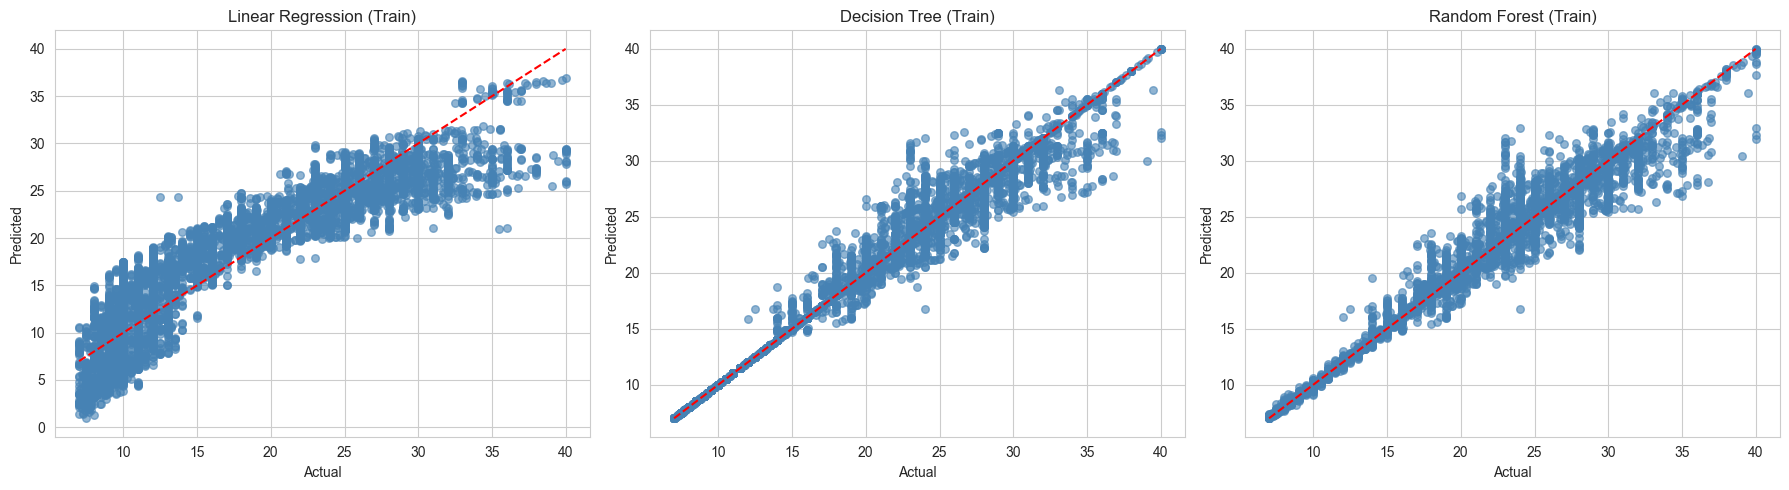

In [58]:
plt.figure(figsize=(18,5))

# 🔹 Linear Regression (Train)
plt.subplot(1,3,1)
preds_lr_train = lr.predict(X_train)
plt.scatter(y_train, preds_lr_train, color=COLOR, alpha=0.6, s=30)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression (Train)")

# 🔹 Decision Tree (Train)
plt.subplot(1,3,2)
preds_dt_train = dt.predict(X_train)
plt.scatter(y_train, preds_dt_train, color=COLOR, alpha=0.6, s=30)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Decision Tree (Train)")

# 🔹 Random Forest (Train)
plt.subplot(1,3,3)
preds_rf_train = rf.predict(X_train)
plt.scatter(y_train, preds_rf_train, color=COLOR, alpha=0.6, s=30)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest (Train)")

plt.tight_layout()
plt.show()

###  Training Graph Interpretation

- **Linear Regression:**  
  Predictions are widely scattered and not close to the ideal line.  
  ➤ This indicates **underfitting (high bias)** — the model is too simple to capture the patterns.

- **Decision Tree:**  
  Predictions lie almost perfectly on the ideal line.  
  ➤ This indicates **overfitting (high variance)** — the model has memorized the training data.

- **Random Forest:**  
  Predictions are close to the ideal line but still show slight variation.  
  ➤ This indicates **good generalization** — the model balances bias and variance effectively.


### Conclusion

- Linear Regression → **Underfitting**  
- Decision Tree → **Overfitting**  
- Random Forest → **Best balance**

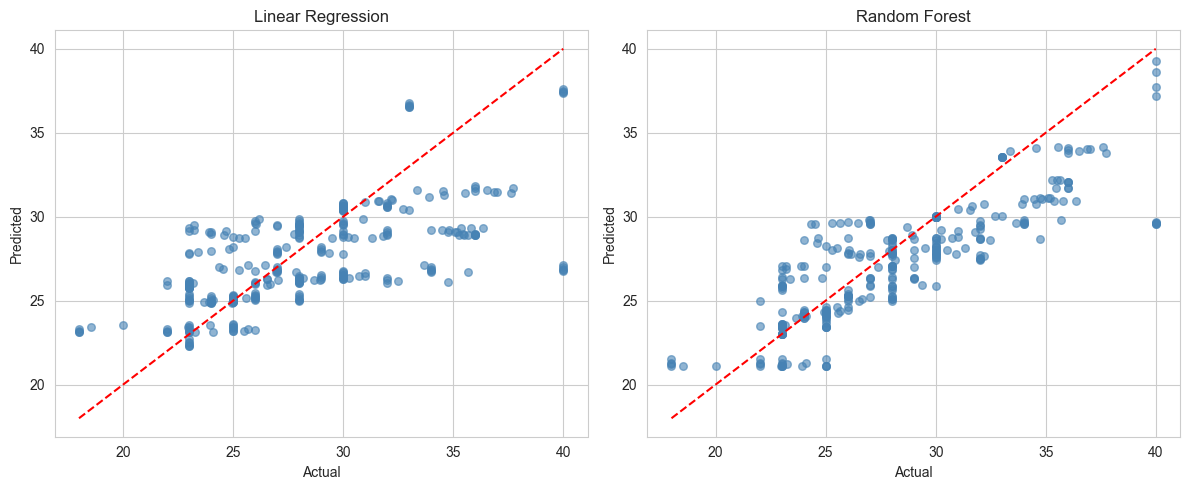

In [59]:
plt.figure(figsize=(12,5))

# Linear Regression
plt.subplot(1,2,1)
preds_lr = lr.predict(X_test)
plt.scatter(y_test, preds_lr, color=COLOR, alpha=0.6, s=30)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression")

# Random Forest
plt.subplot(1,2,2)
preds_rf = rf.predict(X_test)
plt.scatter(y_test, preds_rf, color=COLOR,alpha=0.6, s=30)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest")

plt.tight_layout()
plt.show()

###  Test Data Prediction Comparison

- **Linear Regression:**  
  Predictions are scattered and deviate significantly from the ideal line.  
  ➤ This indicates **underfitting** — the model fails to capture complex patterns in unseen data.

- **Random Forest:**  
  Predictions are much closer to the ideal line with less spread.  
  ➤ This indicates **better accuracy and generalization** — the model captures non-linear relationships effectively.



###  Key Observation

- Points closer to the red dashed line → **better predictions**
- Linear Regression shows higher error  
- Random Forest shows more reliable predictions  



###  Conclusion

- Linear Regression → **Poor performance on test data**  
- Random Forest → **Better generalization and accuracy**  

**→ Random Forest performs significantly better on unseen data**

---

## Limitations

- The model is trained only on rice data and may not generalize to other commodities
- External factors such as weather conditions, inflation, and government policies are not included
- The model relies on historical data and may not fully capture future uncertainties

## Future Scope

- Incorporate external factors such as weather and economic indicators
- Use advanced models like XGBoost or LSTM for better prediction accuracy
- Deploy the model as a web application for real-time usage